<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/28_Sampling_in_Python/01_Introduction_to_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/28_Sampling_in_Python/dataset/spotify_2000_2020.feather"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
spotify_population = pd.read_feather(url)
display(spotify_population.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/churn.csv"
# Read the CSV file
churn = pd.read_csv(url)
display(churn.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/ad_conversion.csv"
# Read the CSV file
ad_conversion = pd.read_csv(url)
display(ad_conversion.head())

,acousticness,artists,danceability,duration_ms,duration_minutes,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.97200,['David Bauer'],0.567,313293.0,5.221550,0.227,0.0,0w0D8H1ubRerCXHWYJkinO,0.601000,10.0,0.110,-13.441,1.0,Shout to the Lord,47.0,2000,0.0290,136.123,0.0396,2000.0
1,0.32100,['Etta James'],0.821,360240.0,6.004000,0.418,0.0,4JVeqfE2tpi7Pv63LJZtPh,0.000372,9.0,0.222,-9.841,0.0,Miss You,51.0,2000-12-12,0.0407,117.382,0.8030,2000.0
2,0.00659,['Quasimoto'],0.706,202507.0,3.375117,0.602,1.0,5pxtdhLAi0RTh1gNqhGMNA,0.000138,11.0,0.400,-8.306,0.0,Real Eyes,44.0,2000-06-13,0.3420,89.692,0.4790,2000.0
3,0.00390,['Millencolin'],0.368,173360.0,2.889333,0.977,0.0,3jRsoe4Vkxa4BMYqGHX8L0,0.000000,11.0,0.350,-2.757,0.0,Penguins & Polarbears,52.0,2000-02-22,0.1270,165.889,0.5480,2000.0
4,0.12200,['Steve Chou'],0.501,344200.0,5.736667,0.511,0.0,4mronxcllhfyhBRqyZi8kU,0.000000,7.0,0.279,-9.836,0.0,黃昏,53.0,2000-12-25,0.0291,78.045,0.1130,2000.0


,has_churned,time_since_first_purchase,time_since_last_purchase
0,0,-1.089221,-0.721322
1,0,1.182983,3.634435
2,0,-0.846156,-0.427582
3,0,0.086942,-0.535672
4,0,-1.166642,-0.672640


,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


**Simple sampling with pandas**
Throughout this chapter, you'll be exploring song data from Spotify. Each row of this population dataset represents a song, and there are over 40,000 rows. Columns include the song name, the artists who performed it, the release year, and attributes of the song like its duration, tempo, and danceability. You'll start by looking at the durations.

Your first task is to sample the Spotify dataset and compare the mean duration of the population with the sample.

spotify_population is available and pandas is loaded as pd.

In [ ]:
# Sample 1000 rows from spotify_population
spotify_sample = spotify_population.sample(n=1000)

# Print the sample
print(spotify_sample)

# Calculate the mean duration in mins from spotify_population
mean_dur_pop = spotify_population["duration_minutes"].mean()

# Calculate the mean duration in mins from spotify_sample
mean_dur_samp = spotify_sample["duration_minutes"].mean()

# Print the means
print(mean_dur_pop)
print(mean_dur_samp)

# Notice that the mean song duration in the sample is similar, but not identical to the mean song duration in the whole population.

**Simple sampling and calculating with NumPy**  
You can also use numpy to calculate parameters or statistics from a list or pandas Series.

You'll be turning it up to eleven and looking at the loudness property of each song.

spotify_population is available and numpy is loaded as np.

In [5]:
# Create a pandas Series from the loudness column of spotify_population
loudness_pop = spotify_population['loudness']

# Sample 100 values of loudness_pop
loudness_samp = loudness_pop.sample(n=100)

# Calculate the mean of loudness_pop
mean_loudness_pop = np.mean(loudness_pop)

# Calculate the mean of loudness_samp
mean_loudness_samp = np.mean(loudness_samp)

print(mean_loudness_pop)
print(mean_loudness_samp)

-7.366856851353947
-7.2283800000000005


**Are findings from the sample generalizable?**  
You just saw how convenience sampling—collecting data using the easiest method—can result in samples that aren't representative of the population. Equivalently, this means findings from the sample are not generalizable to the population. Visualizing the distributions of the population and the sample can help determine whether or not the sample is representative of the population.

The Spotify dataset contains an acousticness column, which is a confidence measure from zero to one of whether the track was made with instruments that aren't plugged in. You'll compare the acousticness distribution of the total population of songs with a sample of those songs.

spotify_population and spotify_mysterious_sample are available; pandas as pd, matplotlib.pyplot as plt, and numpy as np are loaded.

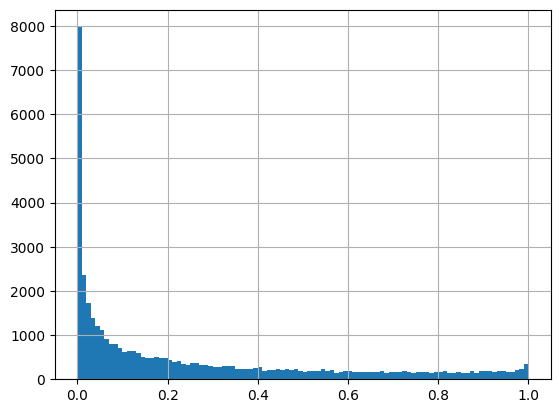

In [6]:
# Visualize the distribution of acousticness with a histogram
spotify_population["acousticness"].hist(width=0.01, bins=np.arange(0,1.01, 0.01))
plt.show()

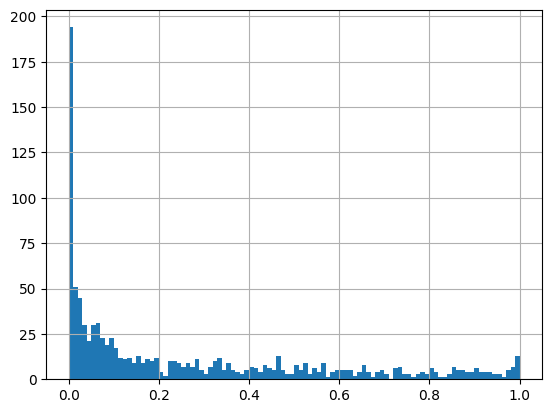

In [8]:
# Update the histogram to use spotify_mysterious_sample
# Sample 1000 rows from spotify_population and assign it to spotify_mysterious_sample
spotify_mysterious_sample = spotify_population.sample(n=1000)
spotify_mysterious_sample['acousticness'].hist(bins=np.arange(0, 1.01, 0.01))
plt.show()

# The acousticness values in the sample are all greater than 0.95, whereas they range from 0 to 1 in the whole population.

**Are these findings generalizable?**   
Let's look at another sample to see if it is representative of the population. This time, you'll look at the duration_minutes column of the Spotify dataset, which contains the length of the song in minutes.

spotify_population and spotify_mysterious_sample2 are available; pandas, matplotlib.pyplot, and numpy are loaded using their standard aliases.

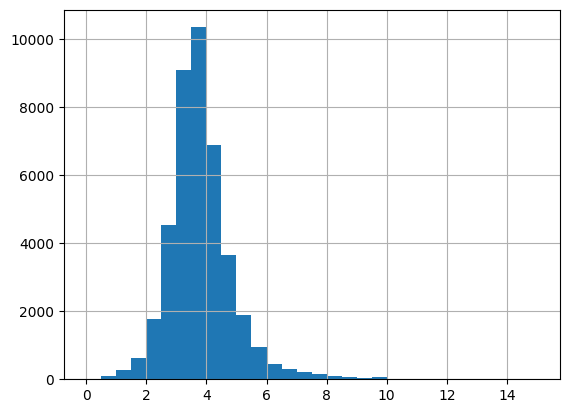

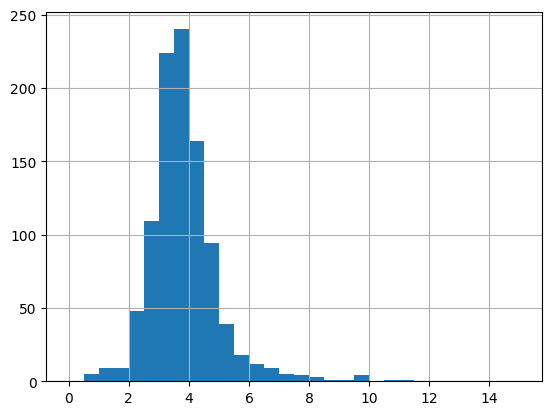

In [13]:
# Update the histogram to use spotify_mysterious_sample2
spotify_population['duration_minutes'].hist(bins=np.arange(0, 15.5, 0.5))
plt.show()

# Sample 1000 rows from spotify_population and assign it to spotify_mysterious_sample2
spotify_mysterious_sample2 = spotify_population.sample(n=1000)

# Update the histogram to use spotify_mysterious_sample2
spotify_mysterious_sample2['duration_minutes'].hist(bins=np.arange(0, 15.5, 0.5))
plt.show()

# Yes. The sample selected is likely a random sample of all songs in the population.

# The duration values in the sample show a similar distribution to those in the whole population, so the results are generalizable.

**Generating random numbers**  
You've used .sample() to generate pseudo-random numbers from a set of values in a DataFrame. A related task is to generate random numbers that follow a statistical distribution, like the uniform distribution or the normal distribution.

Each random number generation function has distribution-specific arguments and an argument for specifying the number of random numbers to generate.

matplotlib.pyplot is loaded as plt, and numpy is loaded as np.

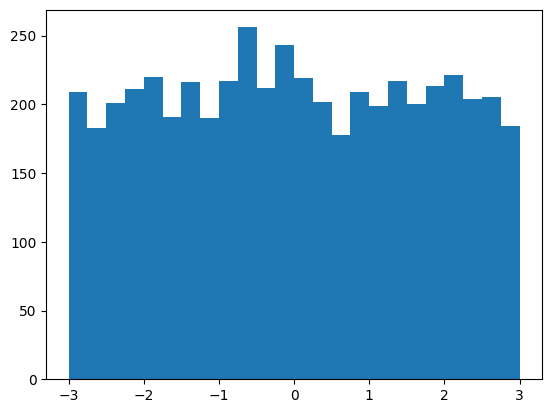

In [14]:
# Generate random numbers from a Uniform(-3, 3)
uniforms = np.random.uniform(low=-3, high=3, size=5000)

# Plot a histogram of uniform values, binwidth 0.25
# Example of setting bins with np.arange to control bin width
bins = np.arange(-3, 3.25, 0.25)
plt.hist(uniforms, bins=bins)
plt.show()
plt.show()

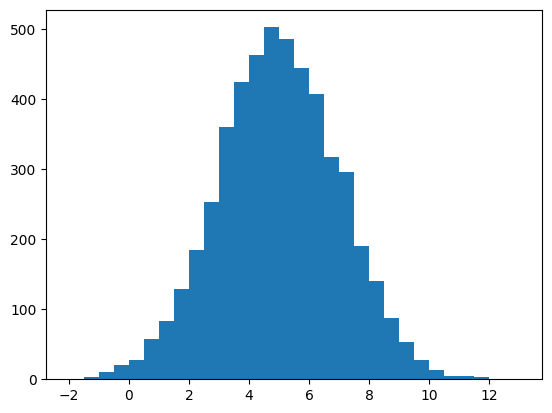

In [15]:
# Generate random numbers from a Normal(5, 2)
normals = np.random.normal(loc=5, scale=2, size=5000)

# Plot a histogram of normal values, binwidth 0.5
# Example of setting bins with np.arange
bins = np.arange(-2, 13.5, 0.5)
plt.hist(normals, bins=bins)
plt.show()
plt.show()

# Notice how the histograms almost take the flat and bell curve shapes of the uniform and normal distributions, but there is a bit of random noise.

**Understanding random seeds**  
While random numbers are important for many analyses, they create a problem: the results you get can vary slightly. This can cause awkward conversations with your boss when your script for calculating the sales forecast gives different answers each time.

Setting the seed for numpy's random number generator helps avoid such problems by making the random number generation reproducible.

Question
Which statement about x and y is true?

      import numpy as np
      np.random.seed(123)
      x = np.random.normal(size=5)
      y = np.random.normal(size=5)



- x and y have identical values.

- The first value of x is identical to the first value of y, but other values are different.

- --The values of x are different from those of y.

Question
Which statement about x and y is true?

      import numpy as np
      np.random.seed(123)
      x = np.random.normal(size=5)
      np.random.seed(123)
      y = np.random.normal(size=5)



- --x and y have identical values.

- The first value of x is identical to the first value of y, but other values are different.

= The values of x are different from those of y.

Question
Which statement about x and y is true?

    import numpy as np
    np.random.seed(123)
    x = np.random.normal(size=5)
    np.random.seed(456)
    y = np.random.normal(size=5)

- x and y have identical values.

- The first value of x is identical to the first value of y, but other values are different.

- --The values of x are different from those of y.